## Handling Missing value dari dataset Titacnic-Dataset.csv

### Tampilkan df.isnull().sum() ketika semua missing value sudah diatasi


In [1]:
import pandas as pd
import numpy as np

path = "Titanic-Dataset.csv"
titanic = pd.read_csv(path)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
percent_missing = 100 * titanic.isnull().mean()
percent_missing


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [5]:
titanic_clean = titanic.drop(columns=['Cabin'])
titanic_clean.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [6]:
titanic_clean['Age'] = titanic_clean['Age'].fillna(titanic_clean['Age'].median())
titanic_clean['Age'].isnull().sum()


np.int64(0)

In [7]:
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode().iloc[0])
titanic_clean['Embarked'].isnull().sum()


np.int64(0)

In [9]:
titanic_clean.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [10]:
print("Jumlah total missing value setelah preprocessing:", titanic_clean.isnull().sum().sum())
titanic_clean.head()

Jumlah total missing value setelah preprocessing: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### Handling outliers dari dataset diabetes.csv

In [11]:
diabetes = pd.read_csv("diabetes.csv")
diabetes.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
selected_cols = ['Insulin', 'BMI', 'SkinThickness']
diabetes[selected_cols].describe()

,Insulin,BMI,SkinThickness
count,768.000000,768.000000,768.000000
mean,79.799479,31.992578,20.536458
std,115.244002,7.884160,15.952218
min,0.000000,0.000000,0.000000
25%,0.000000,27.300000,0.000000
50%,30.500000,32.000000,23.000000
75%,127.250000,36.600000,32.000000
max,846.000000,67.100000,99.000000


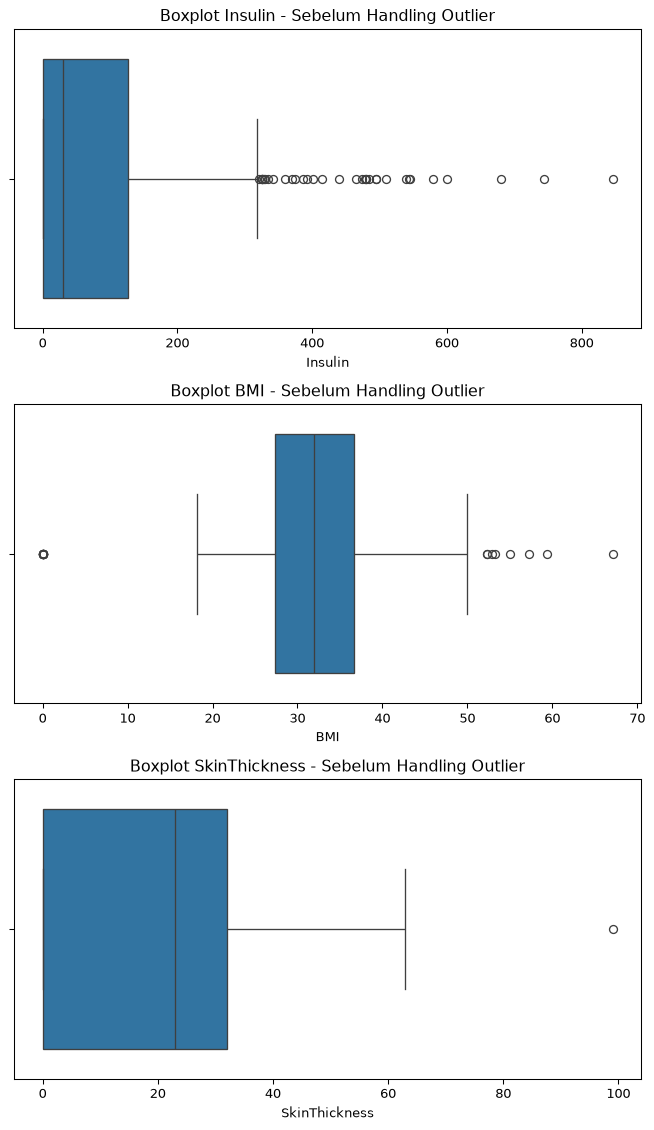

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(len(selected_cols), 1, dpi=95, figsize=(7, 4 * len(selected_cols)))
for i, col in enumerate(selected_cols):
    sns.boxplot(x=diabetes[col], ax=axs[i])
    axs[i].set_xlabel(col)
    axs[i].set_title(f"Boxplot {col} - Sebelum Handling Outlier")
plt.tight_layout()
plt.show()

In [15]:
def get_outlier_bounds(df, col):
    q1, q3 = np.percentile(df[col], [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return lower_bound, upper_bound

for col in selected_cols:
    lower, upper = get_outlier_bounds(diabetes, col)
    n_outliers = diabetes[(diabetes[col] < lower) | (diabetes[col] > upper)].shape[0]
    print(f"{col:15s} -> lower={lower:.2f}, upper={upper:.2f}, jumlah outlier={n_outliers}")


Insulin         -> lower=-190.88, upper=318.12, jumlah outlier=34
BMI             -> lower=13.35, upper=50.55, jumlah outlier=19
SkinThickness   -> lower=-48.00, upper=80.00, jumlah outlier=1


In [16]:
def remove_outliers_sequentially(df, columns):
    df_cleaned = df.copy()
    for col in columns:
        lower_bound, upper_bound = get_outlier_bounds(df_cleaned, col)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

diabetes_clean = remove_outliers_sequentially(diabetes, selected_cols)
print("Jumlah baris sebelum :", diabetes.shape[0])
print("Jumlah baris sesudah :", diabetes_clean.shape[0])
print("Jumlah baris terhapus:", diabetes.shape[0] - diabetes_clean.shape[0])


Jumlah baris sebelum : 768
Jumlah baris sesudah : 715
Jumlah baris terhapus: 53


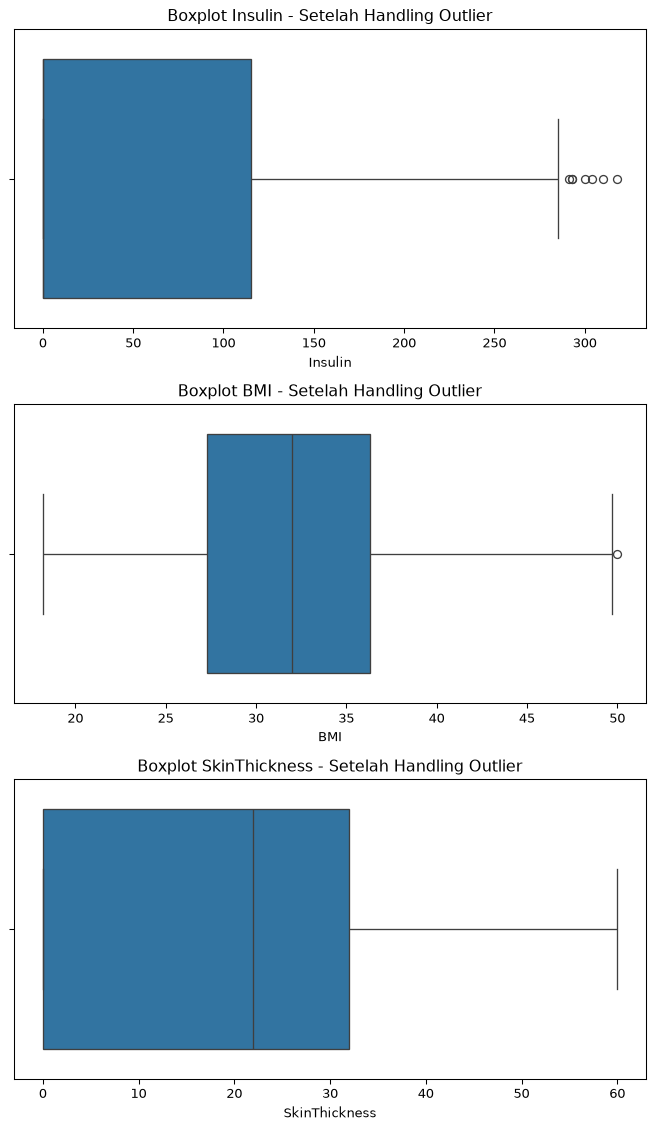

In [17]:
fig, axs = plt.subplots(len(selected_cols), 1, dpi=95, figsize=(7, 4 * len(selected_cols)))
for i, col in enumerate(selected_cols):
    sns.boxplot(x=diabetes_clean[col], ax=axs[i])
    axs[i].set_xlabel(col)
    axs[i].set_title(f"Boxplot {col} - Setelah Handling Outlier")
plt.tight_layout()
plt.show()


In [ ]:
diabetes_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000
mean,3.853147,119.166434,69.594406,19.974825,63.044755,32.096503,0.463938,33.243357,0.335664
std,3.380116,31.251380,18.239858,15.490557,79.363633,6.509947,0.312466,11.637719,0.472553
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,0.000000,0.000000,27.300000,0.243500,24.000000,0.000000
50%,3.000000,115.000000,72.000000,22.000000,0.000000,32.000000,0.368000,29.000000,0.000000
75%,6.000000,138.000000,80.000000,32.000000,115.000000,36.300000,0.613500,41.000000,1.000000
max,17.000000,199.000000,122.000000,60.000000,318.000000,50.000000,2.288000,81.000000,1.000000
